In [1]:
import pandas as pd
import os
import smarts_cerebellum.globals as gl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# DTI metrics
dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
dti = dti[dti.isPatient == 1] # just patients

# behavioural metrics
behav = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'summary_paretic.dat'), sep = '\t')
behav.rename(columns = {'subj_name': 'subj_id', 'week': 'Week'}, inplace = True)
behav['subj_id'] = behav['subj_id'].str.strip()
behav.loc[behav['Week']==1, 'Week'] = 0

# cerebellum GMV
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']
cerebel = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')
cerebel = cerebel[cerebel.isPatient==1] # just patients
cerebel = cerebel[cerebel.regionname.isin(regions)]
cerebel['hemisphere'] = cerebel.regionname.str[2]

/localscratch/tmp/ipykernel_30450/1506670006.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


Note that we have fewer subjects that have BOTH DTI and T1 with behavioural data. So we have some subjs in the DTI dataframe that Jing sent that don't have FaMap images (for some weeks).

In [2]:
print("subjs with behavioural and DTI")
for week in gl.weeks:
    behav_subjs = set(behav.loc[behav.Week == week, 'subj_id'])
    dti_subjs = set(dti.loc[dti.Week == week, 'subj_id'])
    subjs = behav_subjs & dti_subjs # A intersection B
    print(f'week {week}: n = {len(subjs)}')

subjs with behavioural and DTI
week 0: n = 11
week 4: n = 19
week 12: n = 17
week 24: n = 17
week 52: n = 13


# Axial diffusivity ($\lambda_1$)

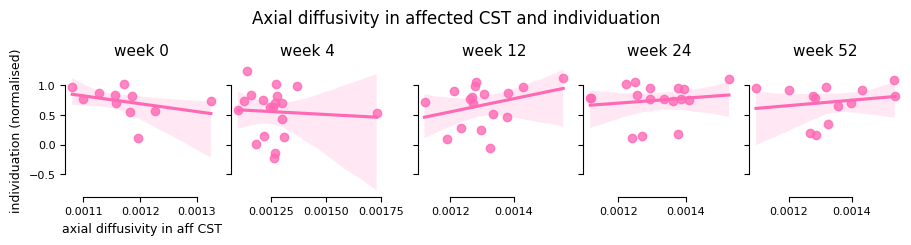

In [3]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'indiv_norm', data = behav_dti_plot, ax = ax, color = 'hotpink')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel(f"axial diffusivity in aff CST")
fig.suptitle(f"Axial diffusivity in affected CST and individuation", y = 1.15)

sns.despine(trim = True)
plt.show()


In [4]:
print("**Pearson R and p-value for AD in affected CST and individuation** \n")
for week in gl.weeks:
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['indiv_norm'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

**Pearson R and p-value for AD in affected CST and individuation** 

week 0: r = -0.35191846332939175, p-value = 0.2885289580306113
week 4: r = -0.06538318862618271, p-value = 0.7902895691982199
week 12: r = 0.3131840790356253, p-value = 0.22094449028576463
week 24: r = 0.1426733912272889, p-value = 0.5848888084070677
week 52: r = 0.18761229262561066, p-value = 0.5393629335922631


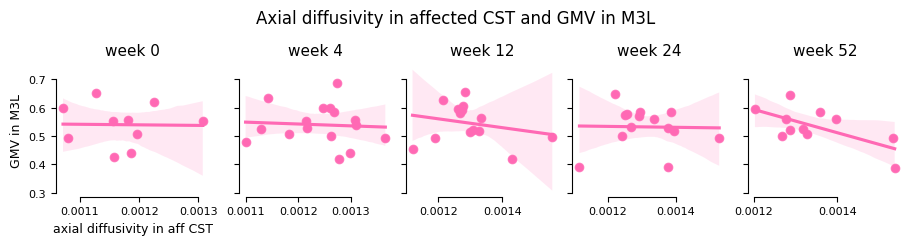

In [5]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    ax = axs[i]
    sns.scatterplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'hotpink')
    sns.regplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'hotpink')
    #sns.scatterplot(x = 'right_norm', y = 'indiv_norm', data =aff_df, ax = ax, edgecolor = None,  legend = False)

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("GMV in M3L")
axs[0].set_xlabel(f"axial diffusivity in aff CST")
fig.suptitle(f"Axial diffusivity in affected CST and GMV in M3L", y = 1.15)


sns.despine(trim = True)
plt.show()


In [6]:
print("**Pearson R and p-value for AD in affected CST and GMV in M3L (cerebellum)** \n")
for week in gl.weeks:
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'lambda_1') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    r_stat, p_stat = stats.pearsonr(cerebel_dti_plot['mean_dti'], cerebel_dti_plot['mean_cerebel'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

**Pearson R and p-value for AD in affected CST and GMV in M3L (cerebellum)** 

week 0: r = -0.018168628067247755, p-value = 0.9602692429195276
week 4: r = -0.06819614946058553, p-value = 0.8018541029168749
week 12: r = -0.2379550092221426, p-value = 0.41267053332510195
week 24: r = -0.022229730806200963, p-value = 0.9398729561706729
week 52: r = -0.650268893015177, p-value = 0.03029443174591395


# Radial diffusivity ($\frac{\lambda_2 + \lambda_3}{2}$)

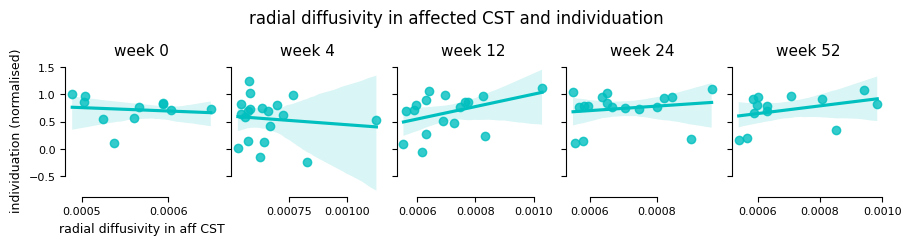

In [7]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    #sns.scatterplot(x = 'mean', y = 'indiv_norm', data = behav_dti_plot, ax = ax, color = 'hotpink')
    sns.regplot(x = 'mean', y = 'indiv_norm', data = behav_dti_plot, ax = ax, color = 'c')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel(f"radial diffusivity in aff CST")
fig.suptitle(f"radial diffusivity in affected CST and individuation", y = 1.15)

sns.despine(trim = True)
plt.show()


In [8]:
print("**Pearson R and p-value for RD in affected CST and individuation** \n")
for week in gl.weeks:
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['indiv_norm'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

**Pearson R and p-value for RD in affected CST and individuation** 

week 0: r = -0.12606425236432475, p-value = 0.7118733481283405
week 4: r = -0.1105097453313703, p-value = 0.6524346749929915
week 12: r = 0.39696079222791697, p-value = 0.11463948372414592
week 24: r = 0.17363804632862903, p-value = 0.5050995022443997
week 52: r = 0.356503357577638, p-value = 0.23182617858005414


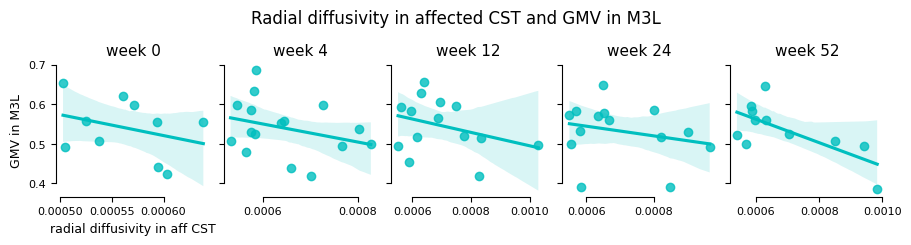

In [9]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    ax = axs[i]
    #sns.scatterplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'hotpink')
    sns.regplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'c')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("GMV in M3L")
axs[0].set_xlabel(f"radial diffusivity in aff CST")
fig.suptitle(f"Radial diffusivity in affected CST and GMV in M3L", y = 1.15)


sns.despine(trim = True)
plt.show()


In [10]:
print("**Pearson R and p-value for RD in affected CST and GMV in M3L (cerebellum)** \n")
for week in gl.weeks:
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'radial_diffusivity') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    r_stat, p_stat = stats.pearsonr(cerebel_dti_plot['mean_dti'], cerebel_dti_plot['mean_cerebel'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

**Pearson R and p-value for RD in affected CST and GMV in M3L (cerebellum)** 

week 0: r = -0.3202308874351389, p-value = 0.3670181895817585
week 4: r = -0.3078816803716893, p-value = 0.24601537586903488
week 12: r = -0.33066110869021825, p-value = 0.24820445148445214
week 24: r = -0.2376673902267099, p-value = 0.4132524967351025
week 52: r = -0.6938365173181541, p-value = 0.017871067331064888


# Fractional anisotropy

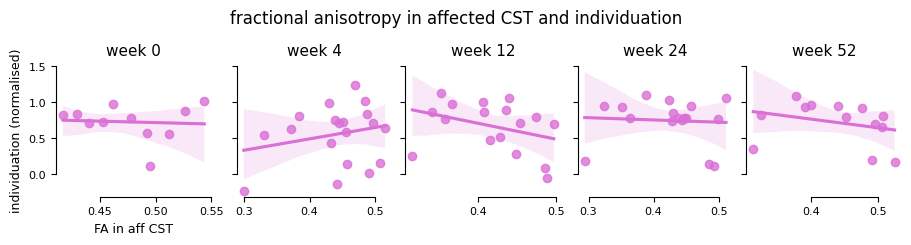

In [11]:
# affected: ipsilesional CST, paretic hand
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    ax = axs[i]
    sns.regplot(x = 'mean', y = 'indiv_norm', data = behav_dti_plot, ax = ax, color = 'orchid')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel(f"FA in aff CST")
fig.suptitle(f"fractional anisotropy in affected CST and individuation", y = 1.15)

sns.despine(trim = True)
plt.show()


In [12]:
print("**Pearson R and p-value for FA in affected CST and individuation** \n")
for week in gl.weeks:
    behav_plot = behav[behav.Week == week]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    behav_dti_plot = pd.merge(dti_plot, behav_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_behav'))

    r_stat, p_stat = stats.pearsonr(behav_dti_plot['mean'], behav_dti_plot['indiv_norm'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

**Pearson R and p-value for FA in affected CST and individuation** 

week 0: r = -0.06614857761710527, p-value = 0.8467758753914307
week 4: r = 0.2305550225603944, p-value = 0.34230602006996347
week 12: r = -0.34872728072232784, p-value = 0.17011133135104958
week 24: r = -0.0630255984884676, p-value = 0.8100932339913309
week 52: r = -0.28517938618521527, p-value = 0.34494417204588157


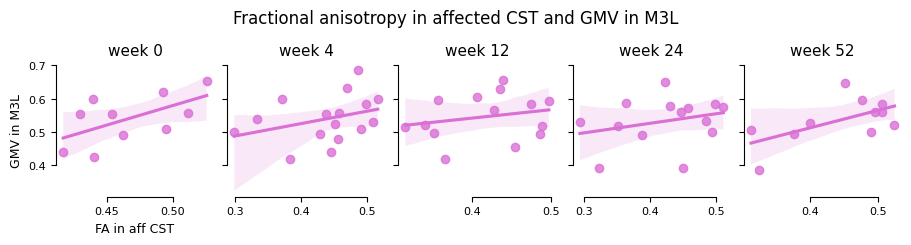

In [13]:
fig, axs = plt.subplots(1, 5, figsize = (9,2), sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    ax = axs[i]
    sns.regplot(x = 'mean_dti', y = 'mean_cerebel', data = cerebel_dti_plot, ax = ax, color = 'orchid')

    ax.set_ylabel('')
    ax.set_xlabel('')

    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("GMV in M3L")
axs[0].set_xlabel(f"FA in aff CST")
fig.suptitle(f"Fractional anisotropy in affected CST and GMV in M3L", y = 1.15)


sns.despine(trim = True)
plt.show()


In [14]:
print("**Pearson R and p-value for FA in affected CST and GMV in M3L (cerebellum)** \n")
for week in gl.weeks:
    cerebel_plot = cerebel[(cerebel.Week == week) & (cerebel.regionname == 'M3L')]
    dti_plot = dti[(dti.Week == week) & (dti.metric == 'FaMap') & (dti.regionname == 'CST_R')]
    cerebel_dti_plot = pd.merge(dti_plot, cerebel_plot, on = ['subj_id', 'Week'], suffixes = ('_dti', '_cerebel'))

    r_stat, p_stat = stats.pearsonr(cerebel_dti_plot['mean_dti'], cerebel_dti_plot['mean_cerebel'])
    print(f'week {week}: r = {r_stat}, p-value = {p_stat}')

**Pearson R and p-value for FA in affected CST and GMV in M3L (cerebellum)** 

week 0: r = 0.5846025027327517, p-value = 0.0759039072919623
week 4: r = 0.33557543800061784, p-value = 0.2038514757491978
week 12: r = 0.22771520207679247, p-value = 0.43364750316616524
week 24: r = 0.2726929242663397, p-value = 0.34555705666086695
week 52: r = 0.5947107364681079, p-value = 0.05363085998962196
